# Exploratory Data Analysis (EDA)
## HomeEstimator AI - Dataset Analysis

This notebook explores our two primary datasets:
1. **Text Dataset**: 240+ labeled job descriptions with category, urgency, and scope labels
2. **Image Dataset**: Home service images organized by category

We analyze distributions, text characteristics, and image properties to inform our modeling decisions.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.dirname(os.getcwd()) if 'notebooks' in os.getcwd() else os.getcwd()
sys.path.insert(0, PROJECT_ROOT)

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
FIGURE_DIR = os.path.join(PROJECT_ROOT, 'report', 'figures')
os.makedirs(FIGURE_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = sns.color_palette('Set2', 6)
print('Setup complete.')

Setup complete.


---
## Part 1: Text Dataset EDA

In [2]:
df = pd.read_csv(os.path.join(DATA_DIR, 'texts', 'job_descriptions.csv'))
print(f'Total text samples: {len(df)}')
print(f'Columns: {list(df.columns)}')
print(f'\nMissing values:\n{df.isnull().sum()}')
df.head()

Total text samples: 295
Columns: ['text', 'category', 'urgency', 'scope']

Missing values:
text        0
category    0
urgency     0
scope       0
dtype: int64


,text,category,urgency,scope
0,"Small drip under the kitchen sink, been going ...",plumbing,low,small
1,"Need to replace the kitchen faucet, it's old a...",plumbing,low,medium
2,Looking to repipe the whole bathroom with copp...,plumbing,low,large
3,The toilet keeps running after flushing. I've ...,plumbing,low,small
4,Want to install a new garbage disposal and con...,plumbing,low,medium


### 1.1 Category Distribution

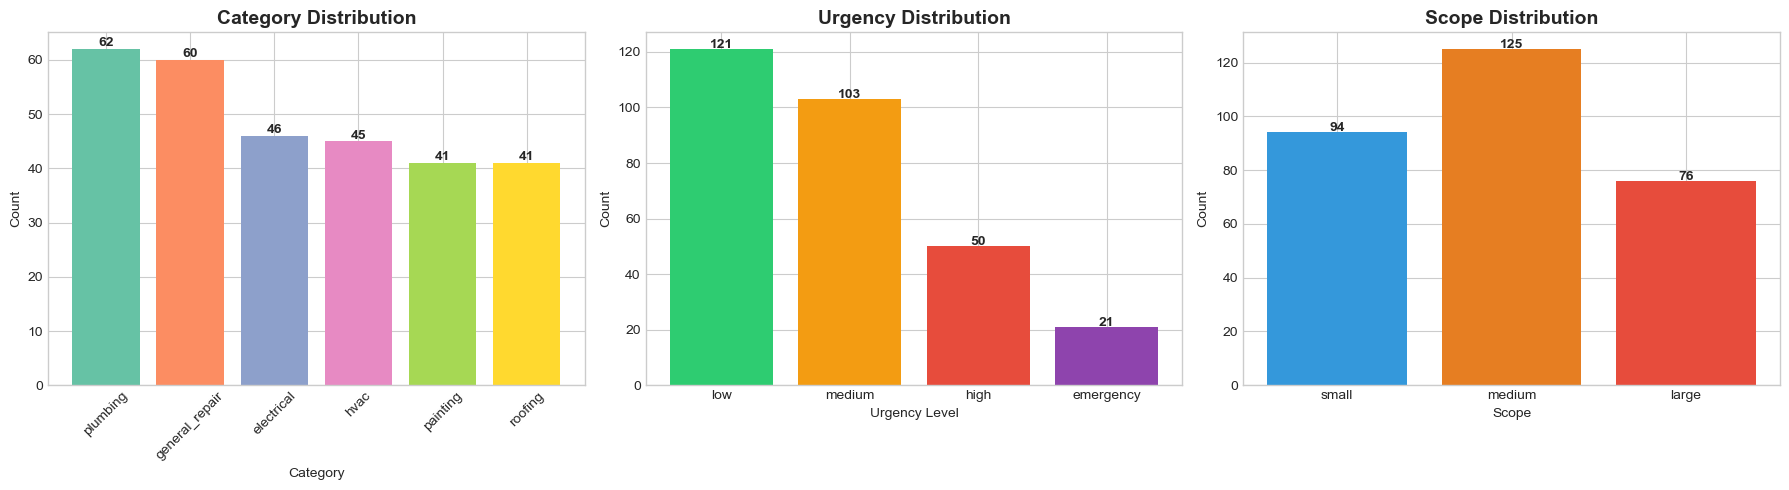

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Category distribution
cat_counts = df['category'].value_counts()
axes[0].bar(cat_counts.index, cat_counts.values, color=COLORS)
axes[0].set_title('Category Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(cat_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Urgency distribution
urg_order = ['low', 'medium', 'high', 'emergency']
urg_counts = df['urgency'].value_counts().reindex(urg_order)
urg_colors = ['#2ecc71', '#f39c12', '#e74c3c', '#8e44ad']
axes[1].bar(urg_counts.index, urg_counts.values, color=urg_colors)
axes[1].set_title('Urgency Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Urgency Level')
axes[1].set_ylabel('Count')
for i, v in enumerate(urg_counts.values):
    axes[1].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Scope distribution
scope_order = ['small', 'medium', 'large']
scope_counts = df['scope'].value_counts().reindex(scope_order)
axes[2].bar(scope_counts.index, scope_counts.values, color=['#3498db', '#e67e22', '#e74c3c'])
axes[2].set_title('Scope Distribution', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Scope')
axes[2].set_ylabel('Count')
for i, v in enumerate(scope_counts.values):
    axes[2].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_label_distributions.png'), dpi=150)
plt.show()

### 1.2 Category vs Urgency Cross-Tabulation

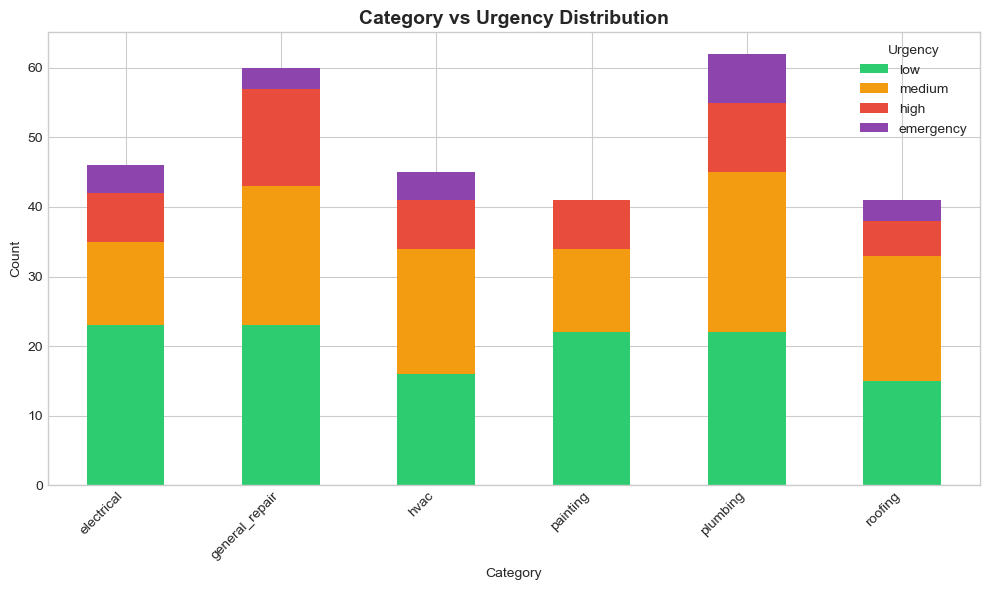

Cross-tabulation:


urgency,low,medium,high,emergency
category,,,,
electrical,23,12,7,4
general_repair,23,20,14,3
hvac,16,18,7,4
painting,22,12,7,0
plumbing,22,23,10,7
roofing,15,18,5,3


In [4]:
cross_tab = pd.crosstab(df['category'], df['urgency'])[urg_order]

fig, ax = plt.subplots(figsize=(10, 6))
cross_tab.plot(kind='bar', stacked=True, color=urg_colors, ax=ax)
ax.set_title('Category vs Urgency Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Count')
ax.legend(title='Urgency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_category_urgency_cross.png'), dpi=150)
plt.show()

print('Cross-tabulation:')
cross_tab

### 1.3 Text Length Analysis

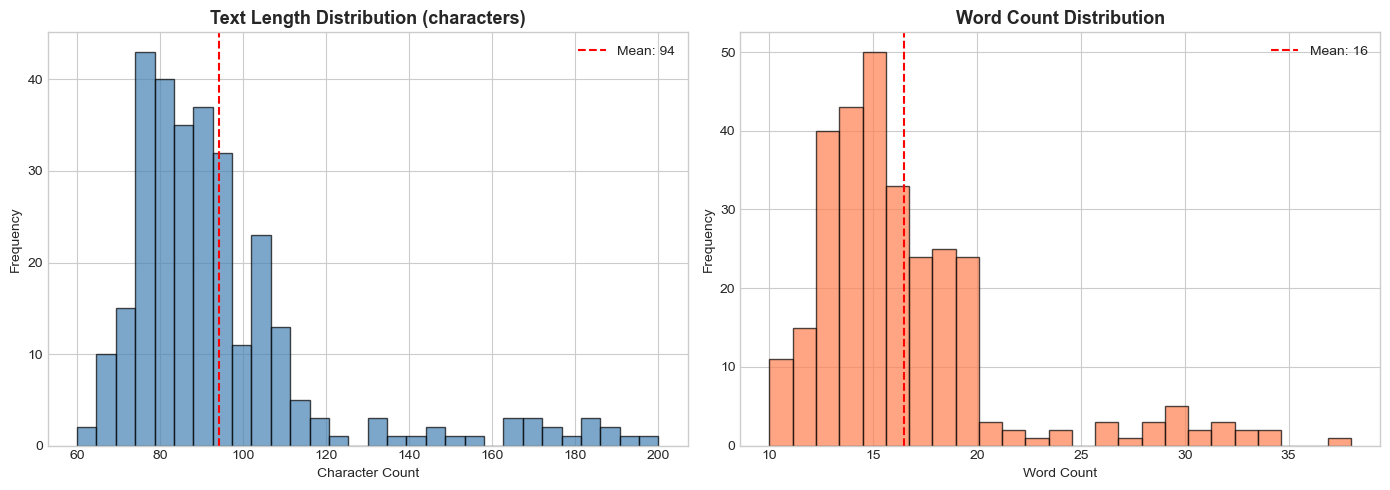

Text length stats: mean=94, median=88, std=25
Word count stats: mean=16, median=15, std=5


In [5]:
df['text_length'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Text length histogram
axes[0].hist(df['text_length'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['text_length'].mean(), color='red', linestyle='--', label=f'Mean: {df["text_length"].mean():.0f}')
axes[0].set_title('Text Length Distribution (characters)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Character Count')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Word count histogram
axes[1].hist(df['word_count'], bins=25, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["word_count"].mean():.0f}')
axes[1].set_title('Word Count Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Word Count')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_text_length.png'), dpi=150)
plt.show()

print(f'Text length stats: mean={df["text_length"].mean():.0f}, median={df["text_length"].median():.0f}, std={df["text_length"].std():.0f}')
print(f'Word count stats: mean={df["word_count"].mean():.0f}, median={df["word_count"].median():.0f}, std={df["word_count"].std():.0f}')

### 1.4 Text Length by Category

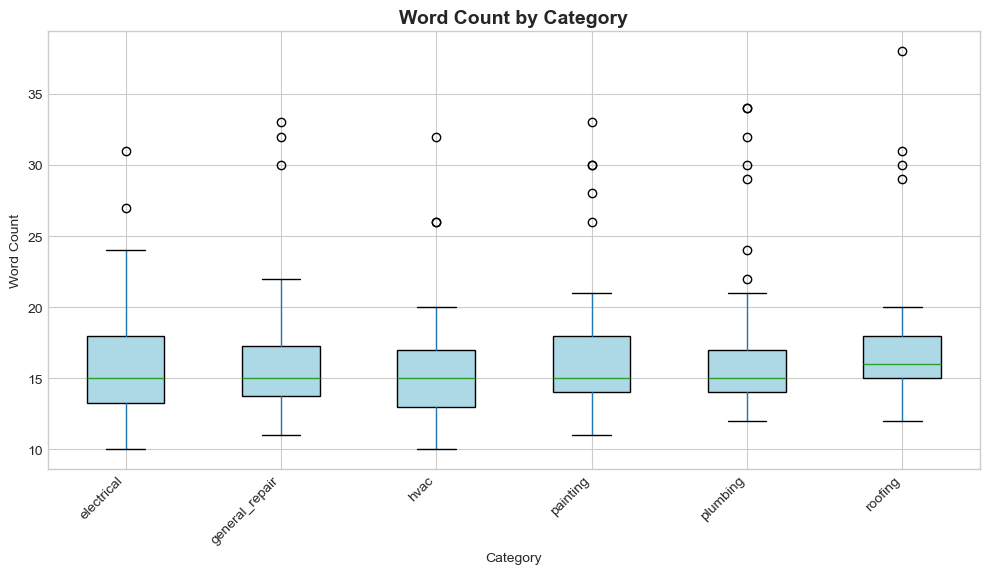

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
df.boxplot(column='word_count', by='category', ax=ax, patch_artist=True,
           boxprops=dict(facecolor='lightblue'))
ax.set_title('Word Count by Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Word Count')
plt.suptitle('')  # Remove automatic title
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_wordcount_by_category.png'), dpi=150)
plt.show()

### 1.5 Word Frequency Analysis

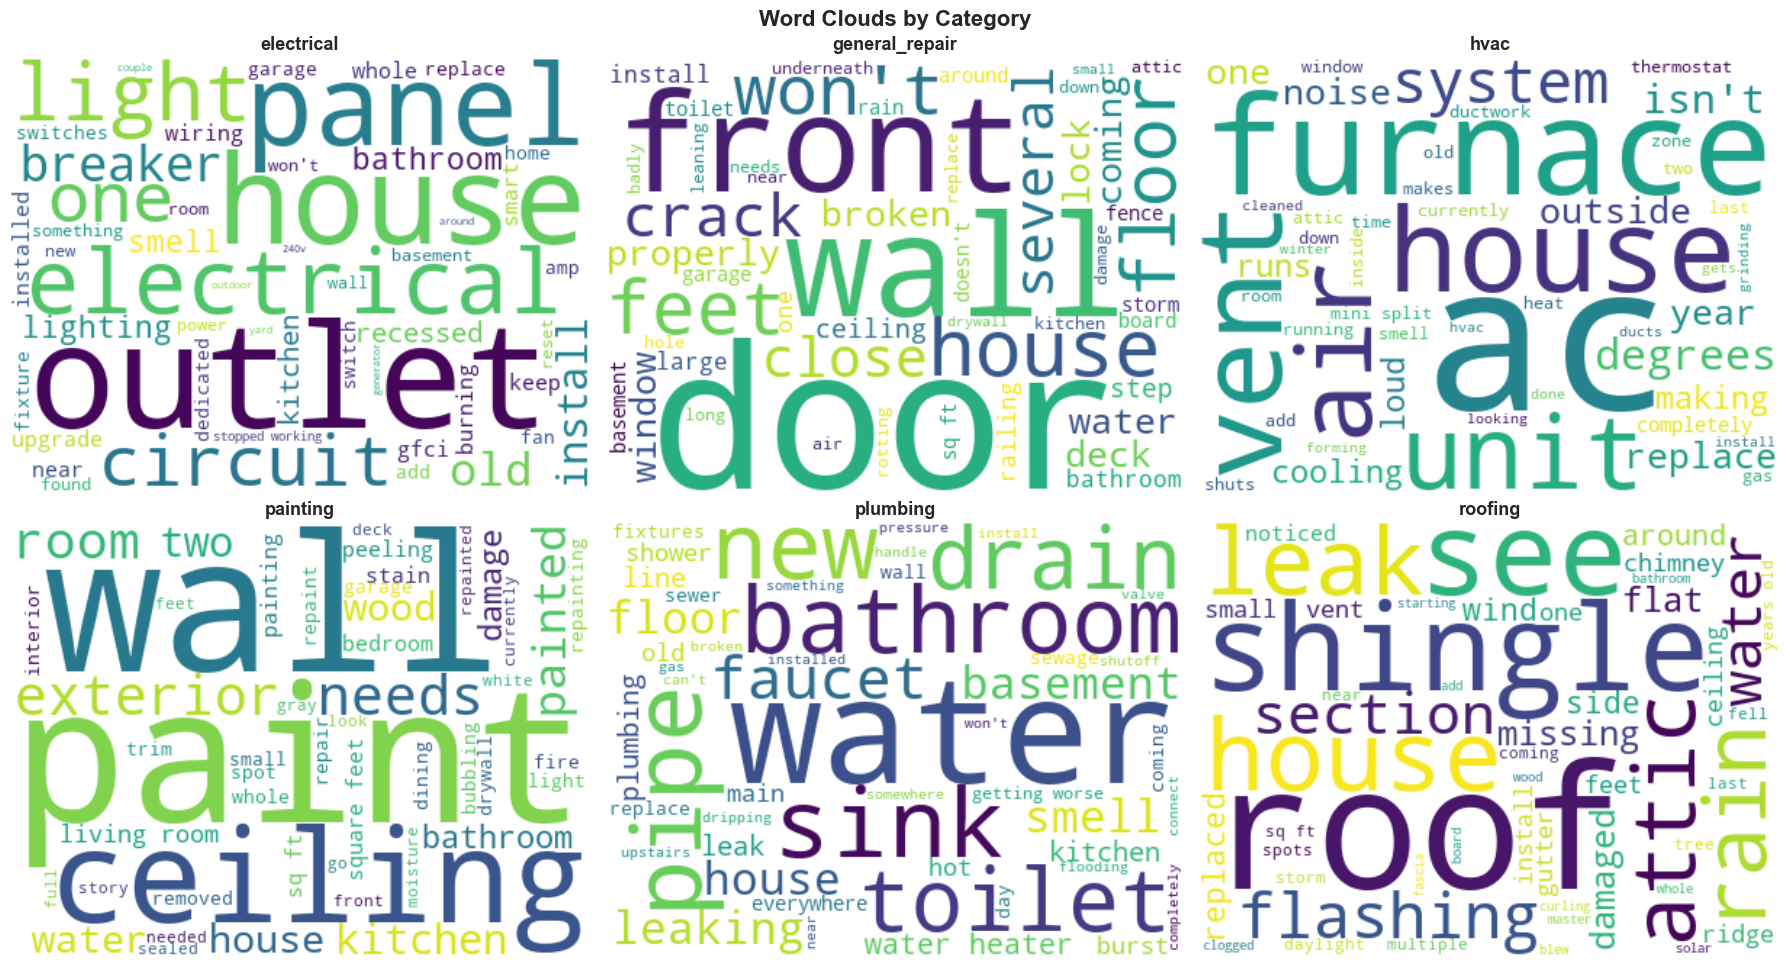

In [7]:
from wordcloud import WordCloud
import re

# Stop words to exclude
stop_words = {'the', 'a', 'an', 'is', 'are', 'was', 'were', 'be', 'been', 'being',
              'have', 'has', 'had', 'do', 'does', 'did', 'will', 'would', 'could',
              'should', 'may', 'might', 'must', 'shall', 'can', 'need', 'dare',
              'to', 'of', 'in', 'for', 'on', 'with', 'at', 'by', 'from', 'as',
              'into', 'through', 'during', 'before', 'after', 'above', 'below',
              'and', 'but', 'or', 'nor', 'not', 'so', 'yet', 'both', 'either',
              'neither', 'each', 'every', 'all', 'any', 'few', 'more', 'most',
              'other', 'some', 'such', 'no', 'only', 'own', 'same', 'than',
              'too', 'very', 'just', 'because', 'if', 'when', 'where', 'how',
              'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those',
              'i', 'me', 'my', 'we', 'our', 'you', 'your', 'he', 'him', 'his',
              'she', 'her', 'it', 'its', 'they', 'them', 'their', 'about', 'up',
              'out', 'off', 'over', 'under', 'again', 'then', 'once', 'here',
              'there', 'also', 'like', 'well', 'back', 'even', 'still', 'way',
              'want', 'get', 'got', 've', 'don', 't', 's', 'going', 'been'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
categories = df['category'].unique()

for idx, (cat, ax) in enumerate(zip(sorted(categories), axes.flat)):
    cat_text = ' '.join(df[df['category'] == cat]['text'].str.lower())
    wc = WordCloud(width=400, height=300, background_color='white',
                   stopwords=stop_words, colormap='viridis',
                   max_words=50)
    wc.generate(cat_text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f'{cat}', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Word Clouds by Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_word_clouds.png'), dpi=150)
plt.show()

### 1.6 Most Common Bigrams per Category

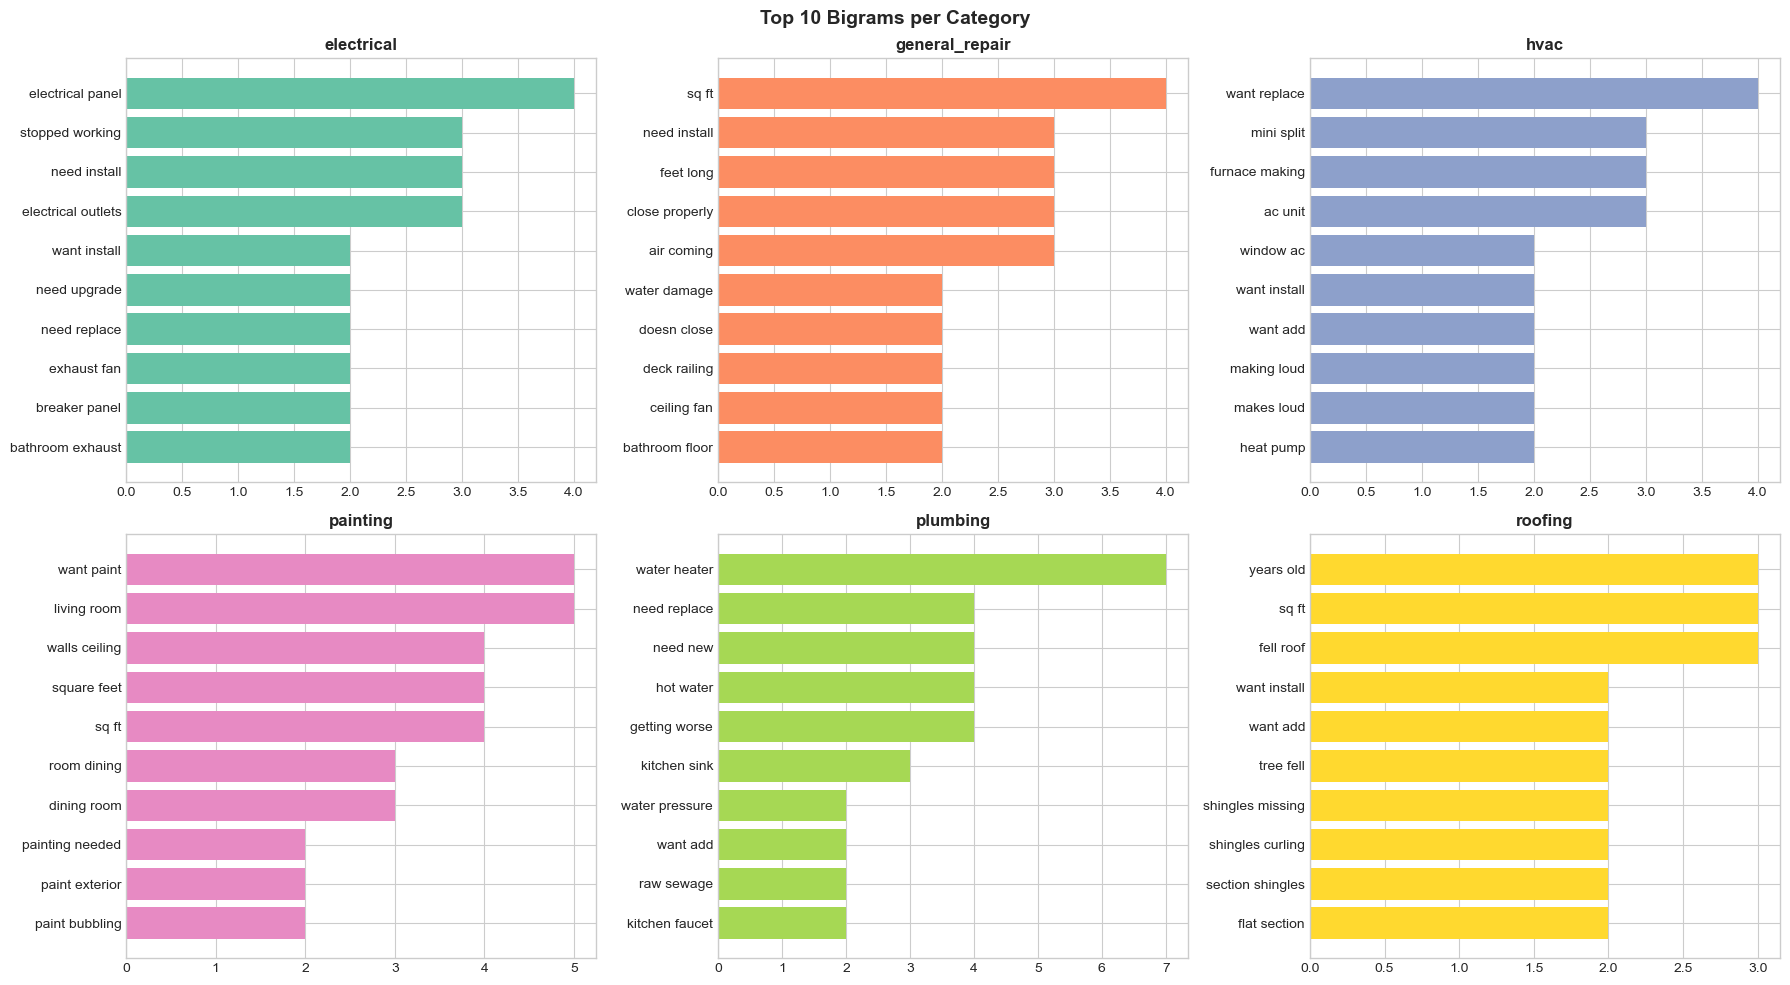

In [8]:
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for idx, (cat, ax) in enumerate(zip(sorted(categories), axes.flat)):
    cat_texts = df[df['category'] == cat]['text'].str.lower()
    vec = CountVectorizer(ngram_range=(2, 2), stop_words='english', max_features=10)
    bigrams = vec.fit_transform(cat_texts)
    bigram_freq = bigrams.sum(axis=0).A1
    bigram_names = vec.get_feature_names_out()
    top_idx = bigram_freq.argsort()[-10:][::-1]
    
    ax.barh([bigram_names[i] for i in top_idx], [bigram_freq[i] for i in top_idx], color=COLORS[idx])
    ax.set_title(f'{cat}', fontsize=12, fontweight='bold')
    ax.invert_yaxis()

plt.suptitle('Top 10 Bigrams per Category', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_top_bigrams.png'), dpi=150)
plt.show()

---
## Part 2: Image Dataset EDA

In [9]:
IMAGE_DIR = os.path.join(DATA_DIR, 'images')
image_counts = {}
image_sizes = {}

for cat in sorted(os.listdir(IMAGE_DIR)):
    cat_dir = os.path.join(IMAGE_DIR, cat)
    if not os.path.isdir(cat_dir):
        continue
    imgs = [f for f in os.listdir(cat_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    image_counts[cat] = len(imgs)
    sizes = []
    for img_name in imgs[:50]:  # Sample first 50
        try:
            img = Image.open(os.path.join(cat_dir, img_name))
            sizes.append(img.size)  # (width, height)
        except:
            pass
    image_sizes[cat] = sizes

print('Image counts per category:')
for cat, count in image_counts.items():
    print(f'  {cat}: {count}')
print(f'\nTotal images: {sum(image_counts.values())}')

Image counts per category:
  electrical: 15
  general_repair: 15
  hvac: 15
  painting: 15
  plumbing: 15
  roofing: 15

Total images: 90


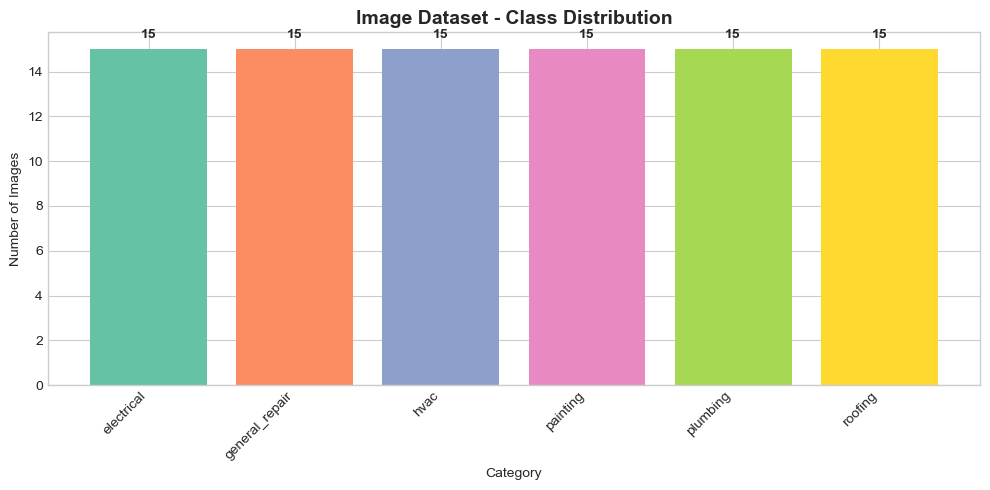

In [10]:
# Image class distribution
fig, ax = plt.subplots(figsize=(10, 5))
cats = list(image_counts.keys())
counts = list(image_counts.values())
ax.bar(cats, counts, color=COLORS[:len(cats)])
ax.set_title('Image Dataset - Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Number of Images')
for i, v in enumerate(counts):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_image_distribution.png'), dpi=150)
plt.show()

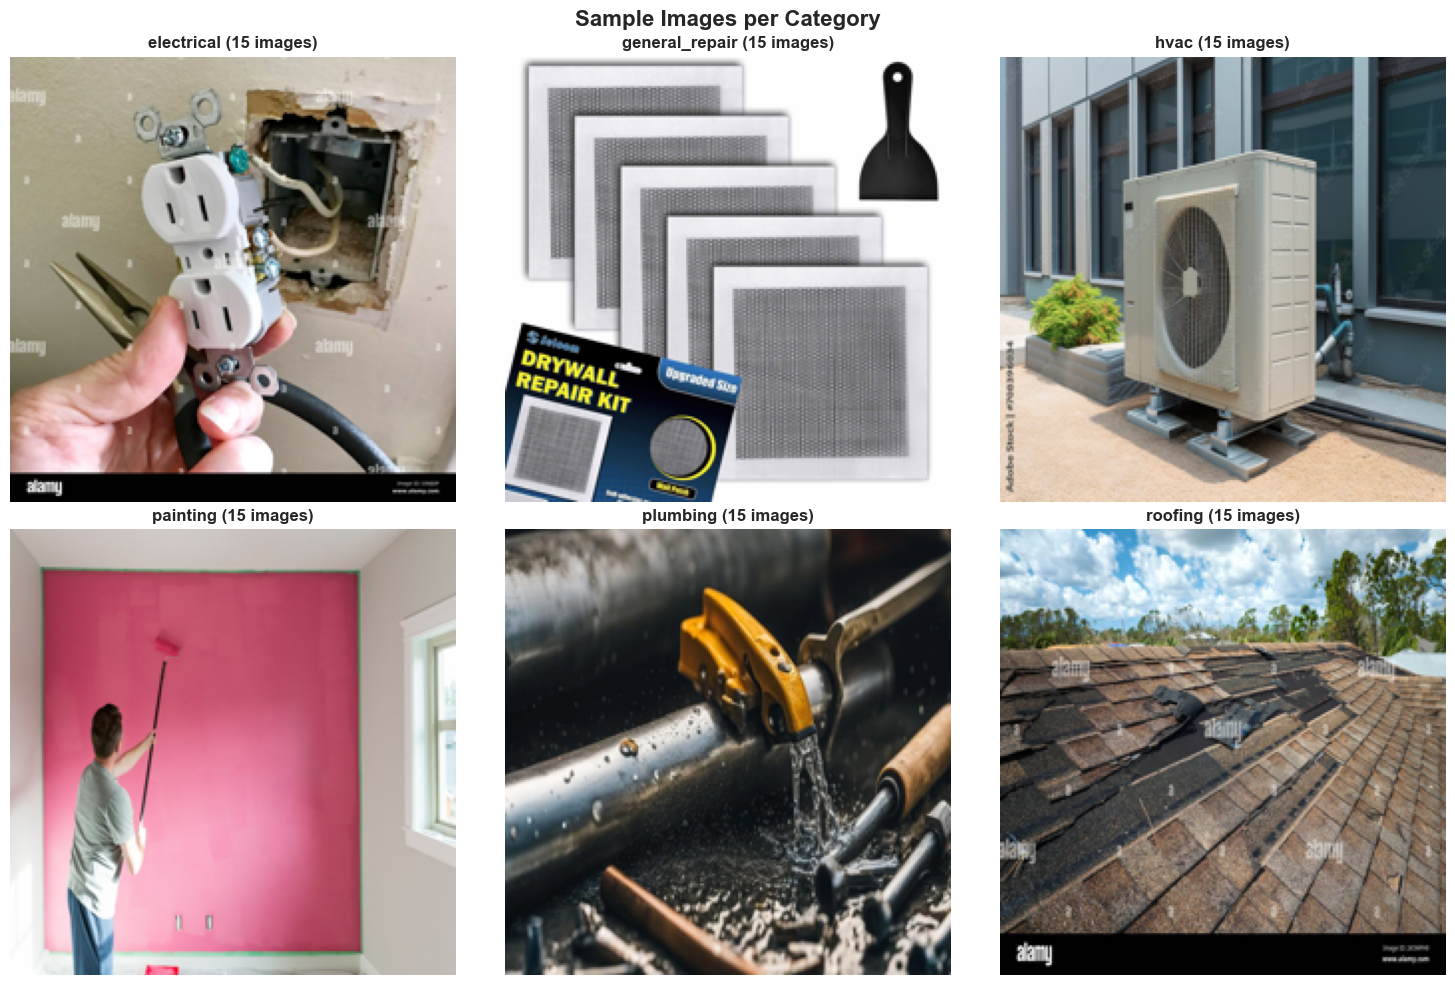

In [11]:
# Sample images grid
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for idx, (cat, ax) in enumerate(zip(sorted(image_counts.keys()), axes.flat)):
    cat_dir = os.path.join(IMAGE_DIR, cat)
    imgs = [f for f in os.listdir(cat_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if imgs:
        try:
            img = Image.open(os.path.join(cat_dir, imgs[0])).convert('RGB')
            img = img.resize((224, 224))
            ax.imshow(img)
        except:
            ax.text(0.5, 0.5, 'No valid image', ha='center', va='center', transform=ax.transAxes)
    else:
        ax.text(0.5, 0.5, 'No images', ha='center', va='center', transform=ax.transAxes)
    ax.set_title(f'{cat} ({len(imgs)} images)', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle('Sample Images per Category', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_sample_images.png'), dpi=150)
plt.show()

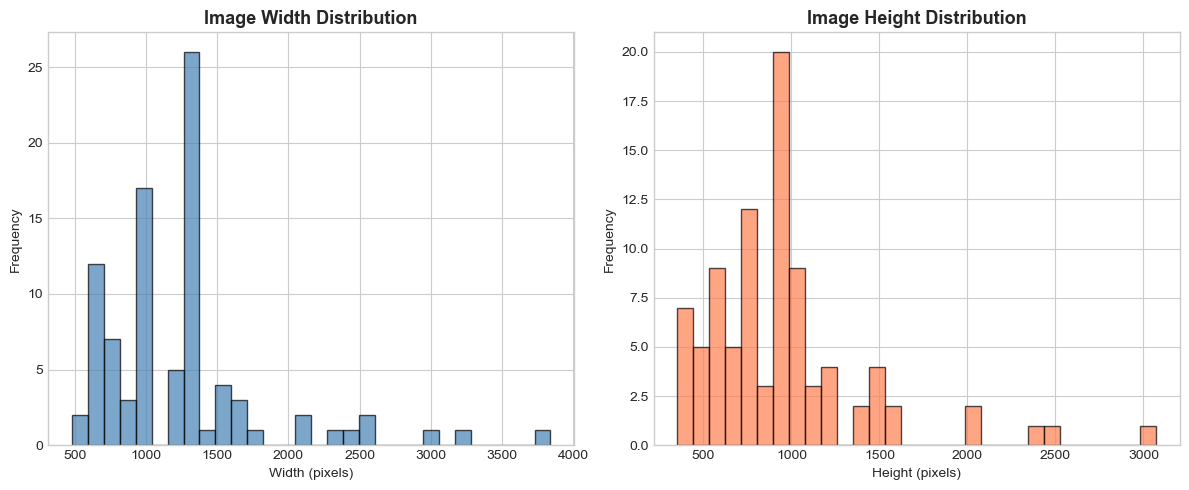

Width stats: mean=1234, min=480, max=3840
Height stats: mean=947, min=352, max=3072


In [12]:
# Image size distribution
all_widths = []
all_heights = []
for cat, sizes in image_sizes.items():
    for w, h in sizes:
        all_widths.append(w)
        all_heights.append(h)

if all_widths:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].hist(all_widths, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].set_title('Image Width Distribution', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Width (pixels)')
    axes[0].set_ylabel('Frequency')

    axes[1].hist(all_heights, bins=30, color='coral', edgecolor='black', alpha=0.7)
    axes[1].set_title('Image Height Distribution', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Height (pixels)')
    axes[1].set_ylabel('Frequency')

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, 'eda_image_sizes.png'), dpi=150)
    plt.show()
    
    print(f'Width stats: mean={np.mean(all_widths):.0f}, min={min(all_widths)}, max={max(all_widths)}')
    print(f'Height stats: mean={np.mean(all_heights):.0f}, min={min(all_heights)}, max={max(all_heights)}')
else:
    print('No images available for size analysis.')

---
## Part 3: Pricing Data Overview

Pricing table: 57 entries

Price range: $50 - $15000


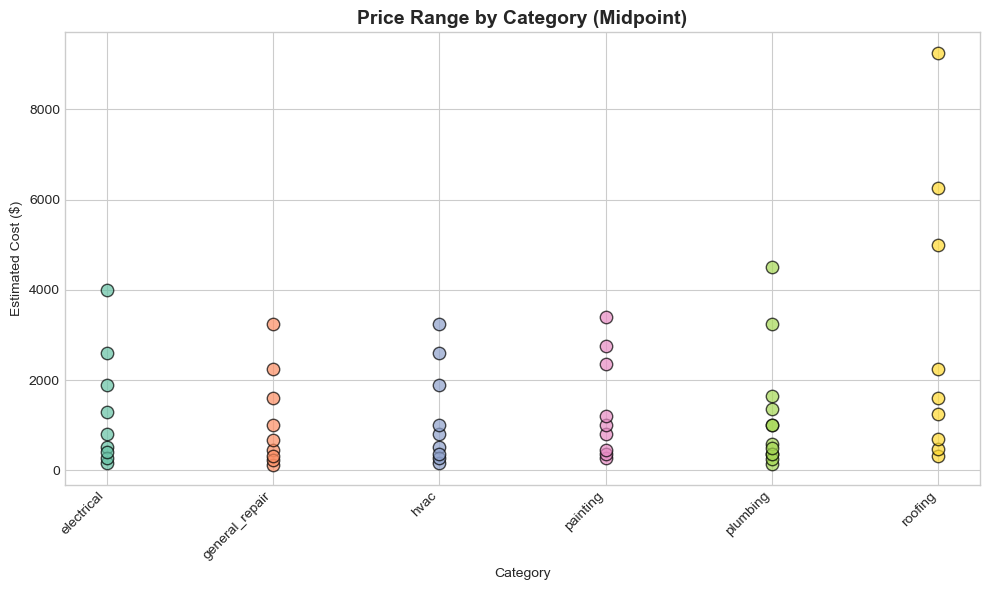

In [13]:
pricing = pd.read_csv(os.path.join(DATA_DIR, 'pricing', 'pricing_table.csv'))
print(f'Pricing table: {len(pricing)} entries')
print(f'\nPrice range: ${pricing["price_low"].min()} - ${pricing["price_high"].max()}')

fig, ax = plt.subplots(figsize=(10, 6))
for idx, cat in enumerate(sorted(pricing['category'].unique())):
    cat_data = pricing[pricing['category'] == cat]
    mid_prices = (cat_data['price_low'] + cat_data['price_high']) / 2
    ax.scatter([cat] * len(mid_prices), mid_prices, color=COLORS[idx], s=80, alpha=0.7, edgecolors='black')

ax.set_title('Price Range by Category (Midpoint)', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Estimated Cost ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'eda_pricing_overview.png'), dpi=150)
plt.show()

## Key Insights

1. **Text Dataset**: Well-balanced across categories with good representation of all urgency levels. Text descriptions vary in length, reflecting real-world variety in how customers describe problems.

2. **Image Dataset**: Images collected across 6 categories provide visual training data for the CV component. Varying image sizes necessitate resizing during preprocessing.

3. **Pricing Data**: Clear price differentiation by category, urgency, and scope. Roofing and HVAC tend to have higher cost ranges; general repair and plumbing small jobs have lower ranges.

4. **Class Balance**: The dataset is reasonably balanced across categories, which is favorable for classifier training without requiring extensive oversampling or class weighting.